# 03 Feature Extraction

In this notebook, we convert windowed physiological signals into machine-learning features.

Each 30-second signal window is transformed into a row of numerical features. These features will later be used to train machine learning models for stress classification.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", PROCESSED_DATA_DIR)
print("Results folder:", RESULTS_DIR)

print("Processed data folder exists:", PROCESSED_DATA_DIR.exists())

Processed data folder: ..\data\processed
Results folder: ..\results
Processed data folder exists: True


In [3]:
X_windows = np.load(PROCESSED_DATA_DIR / "X_windows.npy")
y_windows = np.load(PROCESSED_DATA_DIR / "y_windows.npy")
metadata = pd.read_csv(PROCESSED_DATA_DIR / "window_metadata.csv")

print("X_windows shape:", X_windows.shape)
print("y_windows shape:", y_windows.shape)
print("Metadata shape:", metadata.shape)

X_windows shape: (2151, 21000, 4)
y_windows shape: (2151,)
Metadata shape: (2151, 9)


In [4]:
SIGNAL_NAMES = ["ECG", "EDA", "Resp", "Temp"]

LABEL_NAMES = {
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement"
}

print("Signals:", SIGNAL_NAMES)
print("Labels:", LABEL_NAMES)

Signals: ['ECG', 'EDA', 'Resp', 'Temp']
Labels: {1: 'Neutral / Baseline', 2: 'Stress', 3: 'Amusement'}


In [5]:
example_index = 0

example_window = X_windows[example_index]
example_label = y_windows[example_index]

print("Example window shape:", example_window.shape)
print("Example label:", example_label)
print("Example label name:", LABEL_NAMES[example_label])

Example window shape: (21000, 4)
Example label: 1
Example label name: Neutral / Baseline


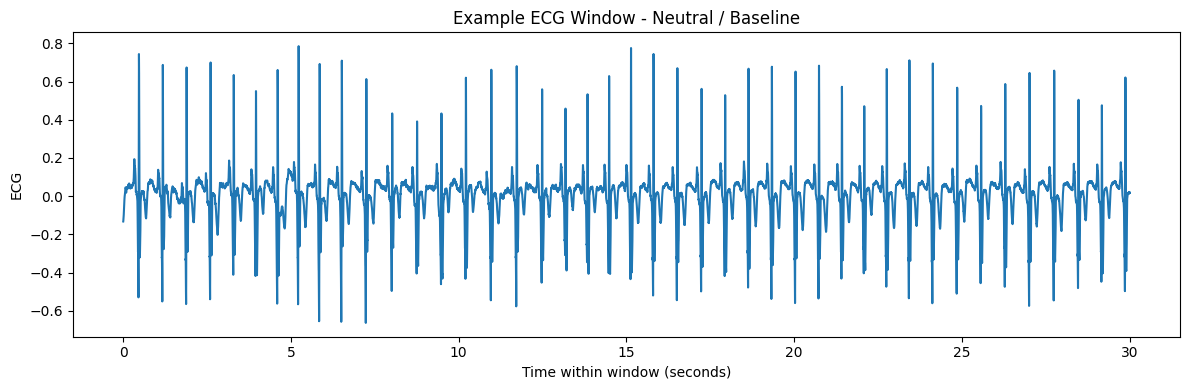

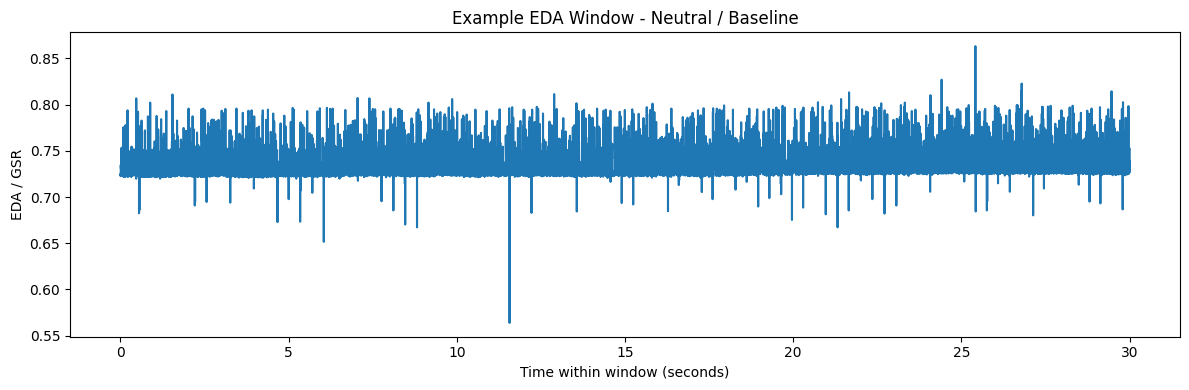

In [6]:
FS_CHEST = 700
WINDOW_SIZE_SEC = 30

time_axis = np.arange(example_window.shape[0]) / FS_CHEST

plt.figure(figsize=(12, 4))
plt.plot(time_axis, example_window[:, 0])
plt.xlabel("Time within window (seconds)")
plt.ylabel("ECG")
plt.title(f"Example ECG Window - {LABEL_NAMES[example_label]}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_axis, example_window[:, 1])
plt.xlabel("Time within window (seconds)")
plt.ylabel("EDA / GSR")
plt.title(f"Example EDA Window - {LABEL_NAMES[example_label]}")
plt.tight_layout()
plt.show()

In [7]:
def extract_basic_features(signal_values):
    """
    Extract basic statistical features from one signal.

    Parameters
    ----------
    signal_values : np.ndarray
        One-dimensional signal values from one window.

    Returns
    -------
    dict
        Dictionary of extracted features.
    """
    signal_values = np.asarray(signal_values)
    
    features = {}
    
    features["mean"] = np.mean(signal_values)
    features["std"] = np.std(signal_values)
    features["min"] = np.min(signal_values)
    features["max"] = np.max(signal_values)
    features["median"] = np.median(signal_values)
    features["range"] = np.max(signal_values) - np.min(signal_values)
    
    features["q25"] = np.percentile(signal_values, 25)
    features["q75"] = np.percentile(signal_values, 75)
    features["iqr"] = features["q75"] - features["q25"]
    
    features["rms"] = np.sqrt(np.mean(signal_values ** 2))
    features["energy"] = np.sum(signal_values ** 2) / len(signal_values)
    
    return features

In [8]:
def calculate_skewness(signal_values):
    """
    Calculate skewness manually.

    Skewness measures whether a signal distribution is asymmetric.
    """
    mean_value = np.mean(signal_values)
    std_value = np.std(signal_values)
    
    if std_value == 0:
        return 0
    
    skewness = np.mean(((signal_values - mean_value) / std_value) ** 3)
    
    return skewness


def calculate_kurtosis(signal_values):
    """
    Calculate kurtosis manually.

    Kurtosis measures whether a signal has sharp peaks or heavy tails.
    """
    mean_value = np.mean(signal_values)
    std_value = np.std(signal_values)
    
    if std_value == 0:
        return 0
    
    kurtosis = np.mean(((signal_values - mean_value) / std_value) ** 4)
    
    return kurtosis

In [9]:
def extract_change_features(signal_values):
    """
    Extract features that describe signal changes over time.

    Parameters
    ----------
    signal_values : np.ndarray
        One-dimensional signal values from one window.

    Returns
    -------
    dict
        Dictionary of signal-change features.
    """
    diff_values = np.diff(signal_values)
    
    features = {}
    
    features["mean_abs_change"] = np.mean(np.abs(diff_values))
    features["std_change"] = np.std(diff_values)
    features["max_abs_change"] = np.max(np.abs(diff_values))
    
    zero_crossings = np.sum(np.diff(np.sign(signal_values)) != 0)
    features["zero_crossings"] = zero_crossings
    
    return features

In [10]:
def extract_features_from_signal(signal_values):
    """
    Extract all features from one signal.

    Parameters
    ----------
    signal_values : np.ndarray
        One-dimensional signal values from one window.

    Returns
    -------
    dict
        Dictionary containing all extracted features.
    """
    features = {}
    
    basic_features = extract_basic_features(signal_values)
    change_features = extract_change_features(signal_values)
    
    features.update(basic_features)
    features.update(change_features)
    
    features["skewness"] = calculate_skewness(signal_values)
    features["kurtosis"] = calculate_kurtosis(signal_values)
    
    return features

In [11]:
example_ecg = example_window[:, 0]

example_ecg_features = extract_features_from_signal(example_ecg)

example_ecg_features

{'mean': np.float64(0.0015163705008370536),
 'std': np.float64(0.13241569643830173),
 'min': np.float64(-0.6638946533203125),
 'max': np.float64(0.7858428955078125),
 'median': np.float64(0.0307159423828125),
 'range': np.float64(1.449737548828125),
 'q25': np.float64(-0.028106689453125),
 'q75': np.float64(0.059967041015625),
 'iqr': np.float64(0.08807373046875),
 'rms': np.float64(0.13242437858165043),
 'energy': np.float64(0.01753621604273628),
 'mean_abs_change': np.float64(0.008067350625094871),
 'std_change': np.float64(0.0225542718397752),
 'max_abs_change': np.float64(0.1849365234375),
 'zero_crossings': np.int64(295),
 'skewness': np.float64(-0.3035578980962765),
 'kurtosis': np.float64(9.329700488821244)}

In [12]:
def extract_features_from_window(window, signal_names):
    """
    Extract features from all signals in one window.

    Parameters
    ----------
    window : np.ndarray
        One window with shape: time steps x channels.
    signal_names : list
        Names of signals/channels.

    Returns
    -------
    dict
        Feature dictionary for one window.
    """
    window_features = {}
    
    for channel_index, signal_name in enumerate(signal_names):
        signal_values = window[:, channel_index]
        signal_features = extract_features_from_signal(signal_values)
        
        for feature_name, feature_value in signal_features.items():
            column_name = f"{signal_name}_{feature_name}"
            window_features[column_name] = feature_value
    
    return window_features

In [13]:
example_window_features = extract_features_from_window(example_window, SIGNAL_NAMES)

print("Number of features:", len(example_window_features))

example_window_features

Number of features: 68


{'ECG_mean': np.float64(0.0015163705008370536),
 'ECG_std': np.float64(0.13241569643830173),
 'ECG_min': np.float64(-0.6638946533203125),
 'ECG_max': np.float64(0.7858428955078125),
 'ECG_median': np.float64(0.0307159423828125),
 'ECG_range': np.float64(1.449737548828125),
 'ECG_q25': np.float64(-0.028106689453125),
 'ECG_q75': np.float64(0.059967041015625),
 'ECG_iqr': np.float64(0.08807373046875),
 'ECG_rms': np.float64(0.13242437858165043),
 'ECG_energy': np.float64(0.01753621604273628),
 'ECG_mean_abs_change': np.float64(0.008067350625094871),
 'ECG_std_change': np.float64(0.0225542718397752),
 'ECG_max_abs_change': np.float64(0.1849365234375),
 'ECG_zero_crossings': np.int64(295),
 'ECG_skewness': np.float64(-0.3035578980962765),
 'ECG_kurtosis': np.float64(9.329700488821244),
 'EDA_mean': np.float64(0.7366500491187686),
 'EDA_std': np.float64(0.013292023715168981),
 'EDA_min': np.float64(0.563812255859375),
 'EDA_max': np.float64(0.8632659912109375),
 'EDA_median': np.float64(0.7

In [14]:
feature_rows = []

for window_index in range(len(X_windows)):
    window = X_windows[window_index]
    
    window_features = extract_features_from_window(window, SIGNAL_NAMES)
    window_features["label"] = y_windows[window_index]
    window_features["label_name"] = LABEL_NAMES[y_windows[window_index]]
    
    feature_rows.append(window_features)
    
    if (window_index + 1) % 100 == 0:
        print("Processed windows:", window_index + 1)

features_df = pd.DataFrame(feature_rows)

print("Feature table shape:", features_df.shape)
features_df.head()

Processed windows: 100
Processed windows: 200
Processed windows: 300
Processed windows: 400
Processed windows: 500
Processed windows: 600
Processed windows: 700
Processed windows: 800
Processed windows: 900
Processed windows: 1000
Processed windows: 1100
Processed windows: 1200
Processed windows: 1300
Processed windows: 1400
Processed windows: 1500
Processed windows: 1600
Processed windows: 1700
Processed windows: 1800
Processed windows: 1900
Processed windows: 2000
Processed windows: 2100
Feature table shape: (2151, 70)


,ECG_mean,ECG_std,ECG_min,ECG_max,ECG_median,ECG_range,ECG_q25,ECG_q75,ECG_iqr,ECG_rms,...,Temp_rms,Temp_energy,Temp_mean_abs_change,Temp_std_change,Temp_max_abs_change,Temp_zero_crossings,Temp_skewness,Temp_kurtosis,label,label_name
0,0.001516,0.132416,-0.663895,0.785843,0.030716,1.449738,-0.028107,0.059967,0.088074,0.132424,...,33.897731,1149.056162,0.022942,0.032233,0.183929,0,-0.302280,3.753279,1,Neutral / Baseline
1,0.000542,0.136359,-0.574814,0.821457,0.031586,1.396271,-0.032192,0.063492,0.095684,0.136360,...,33.922503,1150.736193,0.024211,0.033127,0.177979,0,-0.395398,4.197550,1,Neutral / Baseline
2,0.001889,0.140376,-0.667923,0.821457,0.028976,1.489380,-0.034767,0.067108,0.101875,0.140389,...,33.949085,1152.540389,0.024425,0.033431,0.177979,0,-0.298644,3.715316,1,Neutral / Baseline
3,0.001967,0.154921,-0.667923,0.838211,0.019730,1.506134,-0.053982,0.078690,0.132671,0.154934,...,33.982891,1154.836868,0.024582,0.033548,0.179626,0,-0.029038,3.213001,1,Neutral / Baseline
4,0.000855,0.161409,-0.664948,0.838211,0.005791,1.503159,-0.062416,0.087936,0.150352,0.161411,...,34.028476,1157.937208,0.026112,0.035063,0.179871,0,-0.213312,2.793012,1,Neutral / Baseline


In [15]:
metadata_columns = [
    "subject_id",
    "window_id",
    "start_sec",
    "end_sec",
    "majority_ratio"
]

features_with_metadata = pd.concat(
    [
        metadata[metadata_columns].reset_index(drop=True),
        features_df.reset_index(drop=True)
    ],
    axis=1
)

print("Feature table with metadata shape:", features_with_metadata.shape)

features_with_metadata.head()

Feature table with metadata shape: (2151, 75)


,subject_id,window_id,start_sec,end_sec,majority_ratio,ECG_mean,ECG_std,ECG_min,ECG_max,ECG_median,...,Temp_rms,Temp_energy,Temp_mean_abs_change,Temp_std_change,Temp_max_abs_change,Temp_zero_crossings,Temp_skewness,Temp_kurtosis,label,label_name
0,S10,0,90.0,120.0,0.904762,0.001516,0.132416,-0.663895,0.785843,0.030716,...,33.897731,1149.056162,0.022942,0.032233,0.183929,0,-0.302280,3.753279,1,Neutral / Baseline
1,S10,1,105.0,135.0,1.000000,0.000542,0.136359,-0.574814,0.821457,0.031586,...,33.922503,1150.736193,0.024211,0.033127,0.177979,0,-0.395398,4.197550,1,Neutral / Baseline
2,S10,2,120.0,150.0,1.000000,0.001889,0.140376,-0.667923,0.821457,0.028976,...,33.949085,1152.540389,0.024425,0.033431,0.177979,0,-0.298644,3.715316,1,Neutral / Baseline
3,S10,3,135.0,165.0,1.000000,0.001967,0.154921,-0.667923,0.838211,0.019730,...,33.982891,1154.836868,0.024582,0.033548,0.179626,0,-0.029038,3.213001,1,Neutral / Baseline
4,S10,4,150.0,180.0,1.000000,0.000855,0.161409,-0.664948,0.838211,0.005791,...,34.028476,1157.937208,0.026112,0.035063,0.179871,0,-0.213312,2.793012,1,Neutral / Baseline


In [16]:
missing_values = features_with_metadata.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [17]:
features_with_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2151 entries, 0 to 2150
Data columns (total 75 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            2151 non-null   object 
 1   window_id             2151 non-null   int64  
 2   start_sec             2151 non-null   float64
 3   end_sec               2151 non-null   float64
 4   majority_ratio        2151 non-null   float64
 5   ECG_mean              2151 non-null   float64
 6   ECG_std               2151 non-null   float64
 7   ECG_min               2151 non-null   float64
 8   ECG_max               2151 non-null   float64
 9   ECG_median            2151 non-null   float64
 10  ECG_range             2151 non-null   float64
 11  ECG_q25               2151 non-null   float64
 12  ECG_q75               2151 non-null   float64
 13  ECG_iqr               2151 non-null   float64
 14  ECG_rms               2151 non-null   float64
 15  ECG_energy           

In [18]:
class_distribution = features_with_metadata["label_name"].value_counts().reset_index()
class_distribution.columns = ["label_name", "window_count"]

class_distribution

,label_name,window_count
0,Neutral / Baseline,1154
1,Stress,644
2,Amusement,353


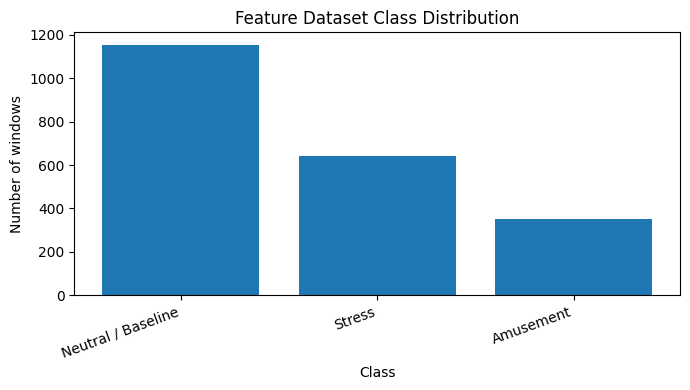

Saved figure to: ..\results\feature_class_distribution.png


In [19]:
plt.figure(figsize=(7, 4))
plt.bar(class_distribution["label_name"], class_distribution["window_count"])
plt.xlabel("Class")
plt.ylabel("Number of windows")
plt.title("Feature Dataset Class Distribution")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "feature_class_distribution.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [20]:
selected_features = [
    "ECG_mean",
    "ECG_std",
    "EDA_mean",
    "EDA_std",
    "Resp_mean",
    "Resp_std",
    "Temp_mean",
    "Temp_std"
]

class_feature_summary = features_with_metadata.groupby("label_name")[selected_features].mean()

class_feature_summary

,ECG_mean,ECG_std,EDA_mean,EDA_std,Resp_mean,Resp_std,Temp_mean,Temp_std
label_name,,,,,,,,
Amusement,0.001122,0.245104,4.436969,0.023809,0.059364,3.050971,34.088850,0.029932
Neutral / Baseline,0.001143,0.250285,3.898279,0.019584,0.057626,2.627850,33.452817,0.035330
Stress,0.001019,0.294980,5.922473,0.077596,0.049103,4.407246,34.163015,0.096839


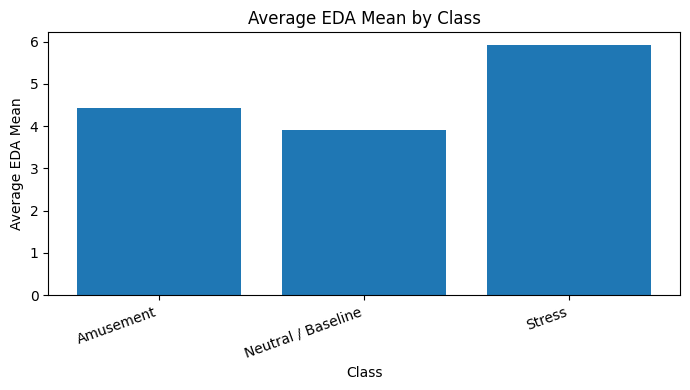

Saved figure to: ..\results\eda_mean_by_class.png


In [21]:
eda_mean_by_class = features_with_metadata.groupby("label_name")["EDA_mean"].mean().reset_index()

plt.figure(figsize=(7, 4))
plt.bar(eda_mean_by_class["label_name"], eda_mean_by_class["EDA_mean"])
plt.xlabel("Class")
plt.ylabel("Average EDA Mean")
plt.title("Average EDA Mean by Class")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "eda_mean_by_class.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [22]:
features_output_path = PROCESSED_DATA_DIR / "features.csv"

features_with_metadata.to_csv(features_output_path, index=False)

print("Saved feature dataset to:", features_output_path)

Saved feature dataset to: ..\data\processed\features.csv


In [23]:
feature_summary_rows = []

feature_summary_rows.append({
    "item": "total_windows",
    "value": len(features_with_metadata)
})

feature_summary_rows.append({
    "item": "total_columns",
    "value": features_with_metadata.shape[1]
})

feature_summary_rows.append({
    "item": "number_of_feature_columns",
    "value": len(example_window_features)
})

feature_summary_rows.append({
    "item": "signals_used",
    "value": ", ".join(SIGNAL_NAMES)
})

for label_name, count in features_with_metadata["label_name"].value_counts().items():
    feature_summary_rows.append({
        "item": f"windows_{label_name}",
        "value": count
    })

feature_summary_df = pd.DataFrame(feature_summary_rows)

feature_summary_df.to_csv(RESULTS_DIR / "feature_extraction_summary.csv", index=False)

feature_summary_df

,item,value
0,total_windows,2151
1,total_columns,75
2,number_of_feature_columns,68
3,signals_used,"ECG, EDA, Resp, Temp"
4,windows_Neutral / Baseline,1154
5,windows_Stress,644
6,windows_Amusement,353


In [24]:
class_feature_summary.to_csv(RESULTS_DIR / "class_feature_summary.csv")

class_feature_summary

,ECG_mean,ECG_std,EDA_mean,EDA_std,Resp_mean,Resp_std,Temp_mean,Temp_std
label_name,,,,,,,,
Amusement,0.001122,0.245104,4.436969,0.023809,0.059364,3.050971,34.088850,0.029932
Neutral / Baseline,0.001143,0.250285,3.898279,0.019584,0.057626,2.627850,33.452817,0.035330
Stress,0.001019,0.294980,5.922473,0.077596,0.049103,4.407246,34.163015,0.096839
